In [1]:
from src.demo_utils import *
from src.methods import run_syflow, run_tree_syflow_corrected, run_tree_classifier_subgroups

# 1 Load Data 

e:\DFKI_DSA\syflow\src\utils\data_loaders.py:196: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["smoker"].replace({"yes":1,"no":0},inplace=True)
e:\DFKI_DSA\syflow\src\utils\data_loaders.py:196: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoker"].replace({"yes":1,"no":0},inplace=True)
e:\D

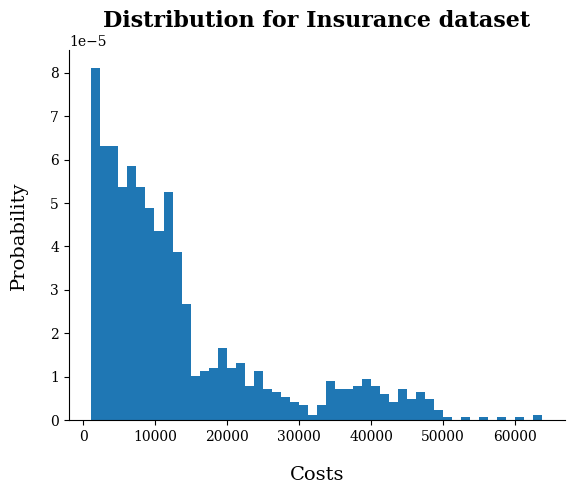

In [2]:
data = load_insurance("data/")
features, target, feature_names = data["data"], data["target"], data["feature_names"]

# print(target)
# print(feature_names)
plot_target(target, "Costs", "Probability", "Distribution for Insurance dataset")

# 2 Discover Subgroups

Logging Hyperparameters
Alpha: 0.3
Lambda: 2.0
Temperature: 0.2 

Discovering Subgroup #1


100%|██████████| 1000/1000 [00:19<00:00, 52.13it/s]


Discovering Subgroup #2


100%|██████████| 1000/1000 [00:18<00:00, 54.55it/s]


Discovering Subgroup #3


100%|██████████| 1000/1000 [00:21<00:00, 46.95it/s]


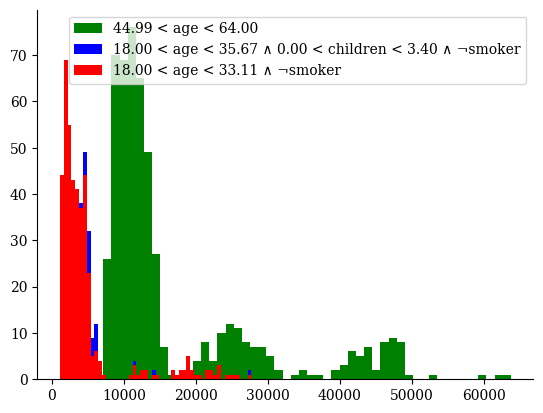

In [3]:
config = SyflowConfig(alpha=0.3, lamb=2.0)
subgroups, rules = run_syflow(features, target.reshape(-1,1), config, 3, feature_names)
plot_subgroups(target, subgroups, rules, which_sgs=[0, 1, 2])

3. TREE SYFLOW - MyTask

Algorithm Tree-SYFLOW(X, Y, n_subgroups, γ, λ, TreeConfig)

1.  // PHASE 1: Generate Candidate Pool (Replaces Gradient Descent Search)
2.  Initialize population statistics: pop_mean, pop_std ← mean(Y), std(Y)
3.  Fit DecisionTreeRegressor(X, Y) using TreeConfig
4.  Candidates ← Empty List
5.  for each Leaf Node L in Tree do:
6.      Mask_L ← Get samples belonging to Leaf L
7.      n_sg ← Sum(Mask_L)
8.      if n_sg < TreeConfig.min_samples then continue
9.
10.     // Calculate "Base Score" (Exceptionality)
11.     // Replaces lines 15-17 in original SYFLOW (KL calculation)
12.     sg_mean, sg_std ← mean(Y[Mask_L]), std(Y[Mask_L])
13.     KL_Exc ← Gaussian_KL(pop_mean, pop_std, sg_mean, sg_std)
14.     Size_Term ← (n_sg / n_total)^γ
15.     Base_Score ← Size_Term * KL_Exc
16.
17.     // Format Rule (Replaces soft-rule parameter extraction)
18.     Rule_L ← Trace_Path_To_Rule(L)
19.     Add {Mask_L, Rule_L, Base_Score, Stats_L} to Candidates
20. end for

21. // PHASE 2: Iterative Selection (Replaces Iterative Loop & Priors)
22. Selected_Subgroups ← Empty List
23. Selected_Stats ← Empty List
24.
25. for k ← 1 to n_subgroups do:
26.     Best_Candidate ← None
27.     Best_Objective ← -Infinity
28.
29.     for each Candidate C in Candidates do:
30.         if C is already in Selected_Subgroups then continue
31.
32.         // Calculate Diversity Penalty (Replaces lines 19-21 in original)
33.         Diversity_Penalty ← 0
34.         for each Prior_Stat P in Selected_Stats do:
35.             Diversity_Penalty ← Diversity_Penalty + Gaussian_KL(C.Stats, P)
36.         end for
37.         if |Selected_Stats| > 0 then
38.             Diversity_Penalty ← Diversity_Penalty / |Selected_Stats|
39.
40.         // Final Objective (Maximize instead of Minimize Loss)
41.         // Corresponds to Line 22: loss ← -Weighted-KL - Regularizer
42.         Total_Score ← C.Base_Score + (λ * Diversity_Penalty)
43.
44.         if Total_Score > Best_Objective then
45.             Best_Objective ← Total_Score
46.             Best_Candidate ← C
47.     end for
48.
49.     Add Best_Candidate to Selected_Subgroups
50.     Add Best_Candidate.Stats to Selected_Stats
51. end for
52.
53. return Selected_Subgroups

['43 < age < 64 ∧ 30 < bmi < 47 ∧ 0 < children < 3 ∧ smoker = 1', '18 < age < 42 ∧ 16 < bmi < 50 ∧ 1 < children < 5 ∧ smoker = 0', '52 < age < 64 ∧ 18 < bmi < 49 ∧ smoker = 0']


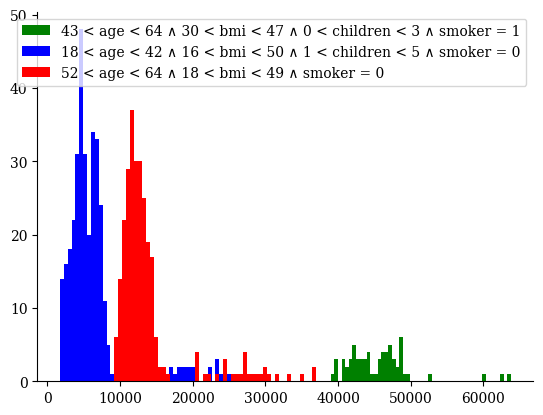

In [4]:
config = SyflowConfig(alpha=0.3, lamb=2.0)
subgroups_tree, rules_tree, scores_tree = run_tree_syflow_corrected(features, target.reshape(-1,1), config,3, feature_names)
print(rules_tree)
plot_subgroups(target, subgroups_tree, rules_tree, which_sgs=[0, 1, 2])

['30 < bmi < 52 ∧ 0 < children < 4 ∧ smoker = 1', '22 < bmi < 29 ∧ 0 < children < 4 ∧ smoker = 1', '47 < age < 64 ∧ 23 < bmi < 49 ∧ smoker = 0']


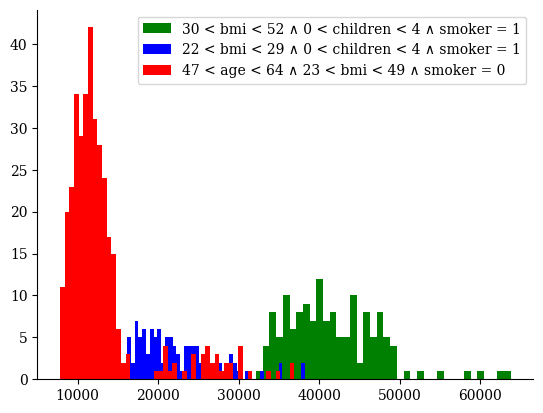

In [5]:
config = SyflowConfig(alpha=0.3, lamb=2.0)
subgroups_tree, rules_tree = run_tree_classifier_subgroups(features, target.reshape(-1,1), config,3, feature_names)
print(rules_tree)
plot_subgroups(target, subgroups_tree, rules_tree, which_sgs=[0, 1, 2])